# MNIST-rot and CIFAR overview

This notebook loads the rotated MNIST files in `downloads/`, loads CIFAR-10 from `downloads/` with a download fallback if the batch files are missing, prints a few summary statistics, and shows example images from both datasets.


In [2]:
import importlib.util
import subprocess
import sys
from pathlib import Path

for package in ("numpy", "matplotlib"):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists():
            return path
    return start


REPO_ROOT = find_repo_root(Path.cwd().resolve())
DOWNLOADS = REPO_ROOT / "downloads"
DOWNLOADS.mkdir(exist_ok=True)
rng = np.random.default_rng(0)


In [7]:
import pickle
import tarfile
import urllib.request

MNIST_ROT_TRAIN = DOWNLOADS / "mnist_rotation_new" / "mnist_rotation_new" / "mnist_all_rotation_normalized_float_train_valid.amat"
MNIST_ROT_TEST = DOWNLOADS / "mnist_rotation_new" / "mnist_rotation_new" / "mnist_all_rotation_normalized_float_test.amat"


def load_mnist_rot(path: Path) -> tuple[np.ndarray, np.ndarray]:
    data = np.loadtxt(path, dtype=np.float32)
    # The .amat files store flattened pixels in the opposite spatial order for imshow.
    images = data[:, :-1].reshape(-1, 28, 28).transpose(0, 2, 1)
    labels = data[:, -1].astype(np.int64)
    return images, labels


def ensure_cifar10(downloads_dir: Path) -> Path:
    cifar_root = downloads_dir / "cifar-10-batches-py"
    required = [cifar_root / f"data_batch_{idx}" for idx in range(1, 6)]
    required += [cifar_root / "test_batch", cifar_root / "batches.meta"]
    if all(path.exists() for path in required):
        return cifar_root

    archive_path = downloads_dir / "cifar-10-python.tar.gz"
    if not archive_path.exists():
        urllib.request.urlretrieve(
            "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz",
            archive_path,
        )

    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(downloads_dir)
    return cifar_root


def load_cifar_batch(path: Path) -> tuple[np.ndarray, np.ndarray]:
    with path.open("rb") as handle:
        batch = pickle.load(handle, encoding="bytes")
    images = np.asarray(batch[b"data"], dtype=np.uint8).reshape(-1, 3, 32, 32)
    images = np.transpose(images, (0, 2, 3, 1))
    labels = np.asarray(batch[b"labels"], dtype=np.int64)
    return images, labels


def load_cifar10(downloads_dir: Path) -> dict[str, np.ndarray | list[str]]:
    cifar_root = ensure_cifar10(downloads_dir)

    train_images = []
    train_labels = []
    for idx in range(1, 6):
        images, labels = load_cifar_batch(cifar_root / f"data_batch_{idx}")
        train_images.append(images)
        train_labels.append(labels)

    test_images, test_labels = load_cifar_batch(cifar_root / "test_batch")

    with (cifar_root / "batches.meta").open("rb") as handle:
        meta = pickle.load(handle, encoding="bytes")
    class_names = [name.decode("utf-8") for name in meta[b"label_names"]]

    return {
        "train_images": np.concatenate(train_images, axis=0),
        "train_labels": np.concatenate(train_labels, axis=0),
        "test_images": test_images,
        "test_labels": test_labels,
        "class_names": class_names,
    }


In [8]:
mnist_train_images, mnist_train_labels = load_mnist_rot(MNIST_ROT_TRAIN)
mnist_test_images, mnist_test_labels = load_mnist_rot(MNIST_ROT_TEST)
cifar10 = load_cifar10(DOWNLOADS)


def describe_split(name: str, images: np.ndarray, labels: np.ndarray, class_names: list[str] | None = None) -> None:
    print(name)
    print(f"  images shape: {images.shape}")
    print(f"  labels shape: {labels.shape}")
    print(f"  pixel mean/std: {images.mean():.4f} / {images.std():.4f}")
    counts = np.bincount(labels)
    if class_names is None:
        summary = {idx: int(count) for idx, count in enumerate(counts)}
    else:
        summary = {class_names[idx]: int(count) for idx, count in enumerate(counts)}
    print(f"  class counts: {summary}")
    print()


describe_split("MNIST-rot train", mnist_train_images, mnist_train_labels)
describe_split("MNIST-rot test", mnist_test_images, mnist_test_labels)
describe_split("CIFAR-10 train", cifar10["train_images"], cifar10["train_labels"], cifar10["class_names"])
describe_split("CIFAR-10 test", cifar10["test_images"], cifar10["test_labels"], cifar10["class_names"])


/tmp/ipykernel_66912/1566475989.py:38: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(handle, encoding="bytes")


MNIST-rot train
  images shape: (12000, 28, 28)
  labels shape: (12000,)
  pixel mean/std: 0.1300 / 0.2970
  class counts: {0: 1184, 1: 1379, 2: 1264, 3: 1215, 4: 1153, 5: 1088, 6: 1187, 7: 1239, 8: 1148, 9: 1143}

MNIST-rot test
  images shape: (50000, 28, 28)
  labels shape: (50000,)
  pixel mean/std: 0.1303 / 0.2973
  class counts: {0: 4999, 1: 5668, 2: 4965, 3: 5108, 4: 4804, 5: 4537, 6: 4971, 7: 5221, 8: 4864, 9: 4863}

CIFAR-10 train
  images shape: (50000, 32, 32, 3)
  labels shape: (50000,)
  pixel mean/std: 120.7076 / 64.1501
  class counts: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}

CIFAR-10 test
  images shape: (10000, 32, 32, 3)
  labels shape: (10000,)
  pixel mean/std: 121.5292 / 64.0610
  class counts: {'airplane': 1000, 'automobile': 1000, 'bird': 1000, 'cat': 1000, 'deer': 1000, 'dog': 1000, 'frog': 1000, 'horse': 1000, 'ship': 1000, 'truck': 1000}



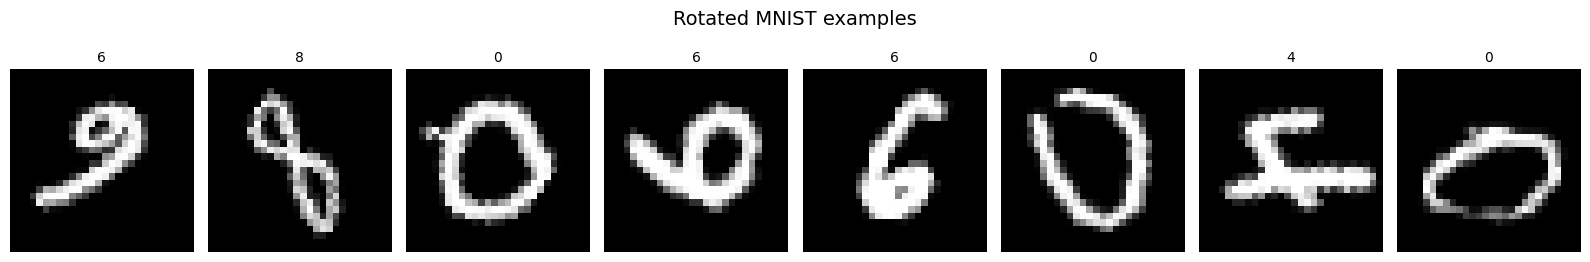

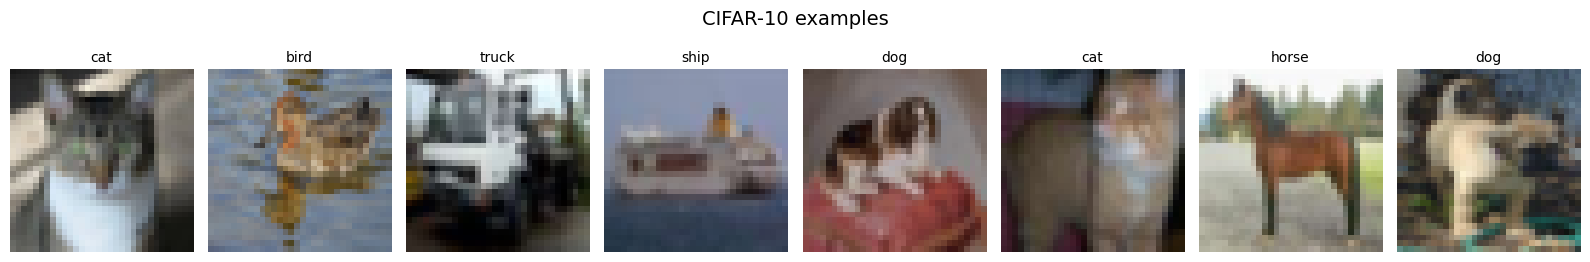

In [9]:
def show_examples(
    images: np.ndarray,
    labels: np.ndarray,
    *,
    title: str,
    class_names: list[str] | None = None,
    cmap: str | None = None,
    n: int = 8,
) -> None:
    indices = rng.choice(len(images), size=n, replace=False)
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.8))
    fig.suptitle(title, fontsize=14)

    for axis, idx in zip(axes, indices):
        axis.imshow(images[idx], cmap=cmap)
        label = int(labels[idx])
        axis.set_title(class_names[label] if class_names is not None else str(label), fontsize=10)
        axis.axis("off")

    plt.tight_layout()
    plt.show()


show_examples(
    mnist_train_images,
    mnist_train_labels,
    title="Rotated MNIST examples",
    cmap="gray",
)

show_examples(
    cifar10["train_images"],
    cifar10["train_labels"],
    title="CIFAR-10 examples",
    class_names=cifar10["class_names"],
)


In [ ]:
single_idx = int(rng.integers(len(cifar10["train_images"])))

plt.figure(figsize=(3, 3), frameon=False)
plt.imshow(cifar10["train_images"][single_idx])
plt.axis("off")
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()